In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("tested.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
print(df.info())
print("/nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None
/nMissing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked    

In [7]:
df['Age'].fillna(df['Age'].median(),inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)
df['Fare'].fillna(df['Fare'].median(),inplace=True)
if 'Cabin' in df.columns:
    df.drop('Cabin',axis=1,inplace=True)
    print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_1528/1781559772.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)
/tmp/ipykernel_1528/1781559772.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [8]:
print("Duplicates before:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:",df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [10]:
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Age']>=lower_bound) & (df['Age']<=upper_bound)]
print(df.shape)

(382, 11)


In [11]:
age_filter=df[df['Age']>30]
print(age_filter.head())

    PassengerId  Survived  Pclass  \
0           892         0       3   
1           893         1       3   
11          903         0       1   
14          906         1       1   
16          908         0       2   

                                                 Name     Sex   Age  SibSp  \
0                                    Kelly, Mr. James    male  34.5      0   
1                    Wilkes, Mrs. James (Ellen Needs)  female  47.0      1   
11                         Jones, Mr. Charles Cresson    male  46.0      0   
14  Chaffee, Mrs. Herbert Fuller (Carrie Constance...  female  47.0      1   
16                                  Keane, Mr. Daniel    male  35.0      0   

    Parch       Ticket     Fare Embarked  
0       0       330911   7.8292        Q  
1       0       363272   7.0000        S  
11      0          694  26.0000        S  
14      0  W.E.P. 5734  61.1750        S  
16      0       233734  12.3500        Q  


In [13]:
female=df[df['Pclass']==1]
print(female.head())

    PassengerId  Survived  Pclass  \
11          903         0       1   
12          904         1       1   
14          906         1       1   
22          914         1       1   
23          915         0       1   

                                                 Name     Sex   Age  SibSp  \
11                         Jones, Mr. Charles Cresson    male  46.0      0   
12      Snyder, Mrs. John Pillsbury (Nelle Stevenson)  female  23.0      1   
14  Chaffee, Mrs. Herbert Fuller (Carrie Constance...  female  47.0      1   
22               Flegenheim, Mrs. Alfred (Antoinette)  female  27.0      0   
23                    Williams, Mr. Richard Norris II    male  21.0      0   

    Parch       Ticket     Fare Embarked  
11      0          694  26.0000        S  
12      0        21228  82.2667        S  
14      0  W.E.P. 5734  61.1750        S  
22      0     PC 17598  31.6833        S  
23      1     PC 17597  61.3792        C  


In [14]:
female=df[df['Sex']== 'female']
print(female.head())

    PassengerId  Survived  Pclass  \
1           893         1       3   
4           896         1       3   
6           898         1       3   
8           900         1       3   
12          904         1       1   

                                             Name     Sex   Age  SibSp  Parch  \
1                Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
6                            Connolly, Miss. Kate  female  30.0      0      0   
8       Abrahim, Mrs. Joseph (Sophie Halaut Easu)  female  18.0      0      0   
12  Snyder, Mrs. John Pillsbury (Nelle Stevenson)  female  23.0      1      0   

     Ticket     Fare Embarked  
1    363272   7.0000        S  
4   3101298  12.2875        S  
6    330972   7.6292        Q  
8      2657   7.2292        C  
12    21228  82.2667        S  


In [15]:
gender=df.groupby('Sex')['Survived'].mean()
print(gender)

Sex
female    1.0
male      0.0
Name: Survived, dtype: float64


In [16]:
print("Total Passengers:",len(df))
print("Total survivors:",df['Survived'].sum())
print("Survival Rate:",df['Survived'].mean()*100)

Total Passengers: 382
Total survivors: 133
Survival Rate: 34.81675392670157


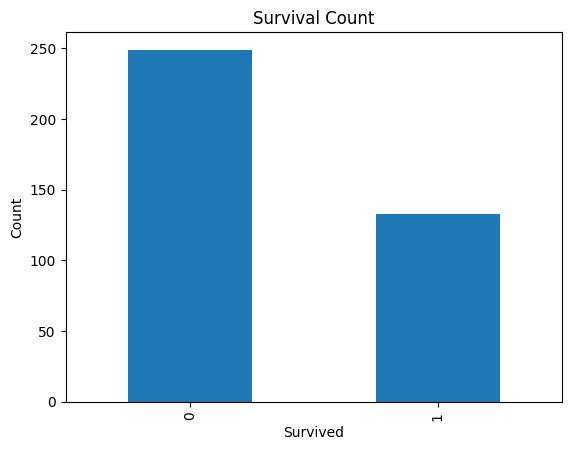

In [17]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

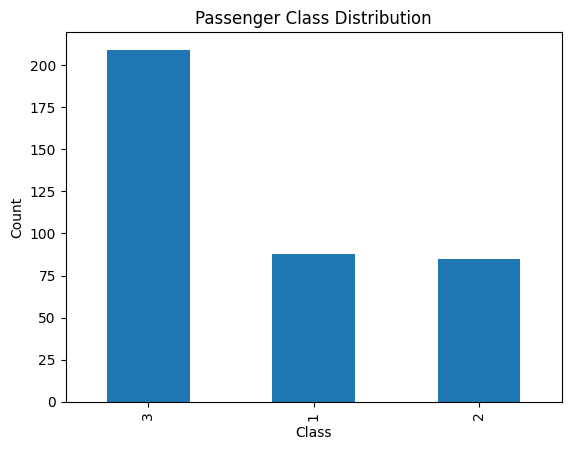

In [18]:
df['Pclass'].value_counts().plot(kind='bar')
plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [20]:
print("/nDataset shape:")
print(df.shape)
print("/nColumns:")
print(df.columns)
print("/nMissing Values:")
print(df.isnull().sum())
print("/nSummary Statistics:")
print(df.describe())
print("/nSurvival by gender:")
print(df.groupby('Sex')['Survived'].mean())
print("/nSurvival by passenger class:")
print(df.groupby('Pclass')['Survived'].mean())

/nDataset shape:
(382, 11)
/nColumns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')
/nMissing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
/nSummary Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   382.000000  382.000000  382.000000  382.000000  382.000000   
mean   1100.123037    0.348168    2.316754   28.418848    0.421466   
std     121.229368    0.477014    0.823973    9.446421    0.918095   
min     892.000000    0.000000    1.000000    5.000000    0.000000   
25%     996.250000    0.000000    2.000000   23.000000    0.000000   
50%    1098.500000    0.000000    3.000000   27.000000    0.000000   
75%    1206.500000    1.000000    3.000000   32.000000    1.000000   
max    1309.000000